<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de lenguaje natural
## Desafío 2 — Custom embeddings con Gensim

**Alumno:** Cristhian Pettico

**Corpus elegido:** *Don Quijote de la Mancha* (Miguel de Cervantes), texto completo de [Project Gutenberg](https://www.gutenberg.org/ebooks/2000).

### Consigna

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado.**

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reducción de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable `MAX_WORDS`) de forma tal que la visualización sea adecuada.
- Inspeccionar el gráfico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones, acompañando los grupos con capturas.

# 0 - Librerías

In [1]:
try:
    from gensim.models import Word2Vec
    import nltk
    import plotly.express as px
except ImportError:
    %pip install -q gensim nltk plotly nbformat
    from gensim.models import Word2Vec
    import nltk
    import plotly.express as px

import platform
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models.callbacks import CallbackAny2Vec
from sklearn.manifold import TSNE

# Recursos de NLTK: modelo para separar oraciones (punkt) y lista de stopwords en español
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords

# 1 - Datos
**Corpus elegido.** *Don Quijote de la Mancha* (primera y segunda parte), descargado de Project Gutenberg.

In [2]:
# Descargar el libro si todavía no está en la carpeta

URL_CORPUS = "https://www.gutenberg.org/cache/epub/2000/pg2000.txt"
ARCHIVO_CORPUS = "pg2000.txt"

if os.access(ARCHIVO_CORPUS, os.F_OK) is False:
    if platform.system() == "Windows":
        !curl -L {URL_CORPUS} -o {ARCHIVO_CORPUS}
    else:
        !wget -q -O {ARCHIVO_CORPUS} {URL_CORPUS}
else:
    print("El corpus ya se encuentra descargado")

El corpus ya se encuentra descargado


In [3]:
with open(ARCHIVO_CORPUS, encoding="utf-8") as f:
    texto_crudo = f.read().replace("\r\n", "\n")  # el archivo viene con saltos de línea de Windows

print("Cantidad de caracteres:", len(texto_crudo))
print("Cantidad de líneas:", texto_crudo.count("\n"))

Cantidad de caracteres: 2130057
Cantidad de líneas: 38059


In [4]:
# Inspección del archivo crudo: cómo empieza y cómo vienen las líneas dentro del libro
print(texto_crudo[:300])
print("\n[...]\n")
for linea in texto_crudo.split("\n")[1071:1077]:
    print(repr(linea))

The Project Gutenberg eBook of Don Quijote
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License inclu

[...]

'En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho'
'tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,'
'rocín flaco y galgo corredor. Una olla de algo más vaca que carnero,'
'salpicón las más noches, duelos y quebrantos los sábados, lantejas los'
'viernes, algún palomino de añadidura los domingos, consumían las tres'
'partes de su hacienda. El resto della concluían sayo de velarte, calzas de'


# 2 - Preprocesamiento

A partir de lo observado en el archivo crudo:

1. **Recortar** el texto entre las marcas de Gutenberg (saca encabezado y licencia en inglés).
2. **Saltear el índice**: el libro propiamente dicho empieza en la palabra `TASA` en mayúsculas (en el índice figura como `Tasa`).
3. **Reconstruir los párrafos**: separar por líneas en blanco y unir las líneas cortadas de cada párrafo.
4. **Separar en oraciones** con `sent_tokenize` de NLTK en español. Cada oración es un "documento" para Word2Vec, en lugar de cada línea del archivo.
5. **Tokenizar** con una expresión regular: pasar a minúsculas y quedarse con las secuencias de letras.
6. **Quitar stopwords** con la lista de español de NLTK.


In [5]:
# Quedarse solo con el libro: lo que está entre las marcas de Gutenberg, salteando el índice
MARCA_INICIO = "*** START OF THE PROJECT GUTENBERG EBOOK"
MARCA_FIN = "*** END OF THE PROJECT GUTENBERG EBOOK"

libro = texto_crudo[texto_crudo.index(MARCA_INICIO):texto_crudo.index(MARCA_FIN)]
libro = libro[libro.index("\nTASA\n"):]

print("Caracteres del archivo original:", len(texto_crudo))
print("Caracteres del libro solo:      ", len(libro))
print()
print(libro[:200])

Caracteres del archivo original: 2130057
Caracteres del libro solo:       2097802


TASA

Yo, Juan Gallo de Andrada, escribano de Cámara del Rey nuestro señor, de
los que residen en su Consejo, certifico y doy fe que, habiendo visto por
los señores dél un libro intitulado El ingenio


In [6]:
# Párrafos: separados por líneas en blanco. Dentro de cada uno se unen las líneas cortadas
parrafos = [re.sub(r"\s+", " ", p).strip() for p in re.split(r"\n\s*\n", libro)]
parrafos = [p for p in parrafos if p]

# Oraciones: cada párrafo se separa en oraciones con NLTK (modelo para español)
oraciones = []
for p in parrafos:
    oraciones.extend(sent_tokenize(p, language="spanish"))

print("Cantidad de párrafos:", len(parrafos))
print("Cantidad de oraciones (documentos):", len(oraciones))
print()
for o in oraciones[1000:1003]:
    print("-", o)


Cantidad de párrafos: 5192
Cantidad de oraciones (documentos): 10844

- Anoche supimos la muerte de Grisóstomo, y que en este lugar había de ser enterrado; y así, de curiosidad y de lástima, dejamos nuestro derecho viaje, y acordamos de venir a ver con los ojos lo que tanto nos había lastimado en oíllo.
- Y, en pago desta lástima y del deseo que en nosotros nació de remedialla si pudiéramos, te rogamos, ¡oh discreto Ambrosio!
- (a lo menos, yo te lo suplico de mi parte), que, dejando de abrasar estos papeles, me dejes llevar algunos dellos.


In [7]:
# Tokenización: minúsculas y solo secuencias de letras (incluye vocales acentuadas, ü y ñ)
def tokenizar(oracion):
    return re.findall(r"[a-záéíóúüñ]+", oracion.lower())


In [8]:
# Stopwords del español (NLTK), ampliadas con dos grupos que la lista estándar no cubre:

STOPWORDS_EXTRA = {"si", "tan", "así", "pues", "sino", "aunque", "tanto", "luego", "aquí", "allí", "acá", "allá",
                   "desta", "deste", "destas", "destos", "della", "dello", "dellas", "dellos", "dél", "esotro",
                   "agora", "ansí", "mesmo", "ésa", "ése", "ésta", "éste"}

stopwords_es = set(stopwords.words("spanish")) | STOPWORDS_EXTRA
print("Stopwords usadas:", len(stopwords_es), f"({len(stopwords.words('spanish'))} de NLTK + {len(STOPWORDS_EXTRA)} agregadas)")

tokens_con_sw = [tokenizar(o) for o in oraciones]
sentence_tokens = [[t for t in doc if t not in stopwords_es] for doc in tokens_con_sw]

Stopwords usadas: 341 (313 de NLTK + 29 agregadas)


In [9]:
# Se descartan las oraciones que quedan con menos de 2 tokens: no aportan ningún par (palabra, contexto)
sentence_tokens = [doc for doc in sentence_tokens if len(doc) > 1]

print("Tokens antes de sacar stopwords:", sum(len(d) for d in tokens_con_sw))
print("Tokens después:                 ", sum(len(d) for d in sentence_tokens))
print("Documentos (oraciones) finales: ", len(sentence_tokens))
print()
print("Oración original:", oraciones[1000])
print("Tokenizada      :", tokens_con_sw[1000])
print("Sin stopwords   :", [t for t in tokens_con_sw[1000] if t not in stopwords_es])

Tokens antes de sacar stopwords: 381311
Tokens después:                  173650
Documentos (oraciones) finales:  10594

Oración original: Anoche supimos la muerte de Grisóstomo, y que en este lugar había de ser enterrado; y así, de curiosidad y de lástima, dejamos nuestro derecho viaje, y acordamos de venir a ver con los ojos lo que tanto nos había lastimado en oíllo.
Tokenizada      : ['anoche', 'supimos', 'la', 'muerte', 'de', 'grisóstomo', 'y', 'que', 'en', 'este', 'lugar', 'había', 'de', 'ser', 'enterrado', 'y', 'así', 'de', 'curiosidad', 'y', 'de', 'lástima', 'dejamos', 'nuestro', 'derecho', 'viaje', 'y', 'acordamos', 'de', 'venir', 'a', 'ver', 'con', 'los', 'ojos', 'lo', 'que', 'tanto', 'nos', 'había', 'lastimado', 'en', 'oíllo']
Sin stopwords   : ['anoche', 'supimos', 'muerte', 'grisóstomo', 'lugar', 'ser', 'enterrado', 'curiosidad', 'lástima', 'dejamos', 'derecho', 'viaje', 'acordamos', 'venir', 'ver', 'ojos', 'lastimado', 'oíllo']


In [10]:
# Vocabulario: palabras distintas y cuántas sobreviven a distintas frecuencias mínimas
frecuencias = pd.Series([t for doc in sentence_tokens for t in doc]).value_counts()

print("Palabras distintas:", len(frecuencias))
for minimo in [2, 5, 10, 20]:
    print(f"  con al menos {minimo:>2} apariciones: {(frecuencias >= minimo).sum()}")

largos = pd.Series([len(doc) for doc in sentence_tokens])
print("\nLargo de las oraciones en tokens -> mediana:", int(largos.median()),
      "| promedio:", round(largos.mean(), 1), "| máximo:", largos.max())

print("\nLas 20 palabras más frecuentes:")
print(", ".join(frecuencias.index[:20]))


Palabras distintas: 22633
  con al menos  2 apariciones: 11466
  con al menos  5 apariciones: 5042
  con al menos 10 apariciones: 2780
  con al menos 20 apariciones: 1463

Largo de las oraciones en tokens -> mediana: 13 | promedio: 16.4 | máximo: 222

Las 20 palabras más frecuentes:
don, quijote, sancho, dijo, señor, ser, bien, respondió, merced, dos, caballero, decir, hacer, dios, señora, aquel, mal, cosa, buen, verdad


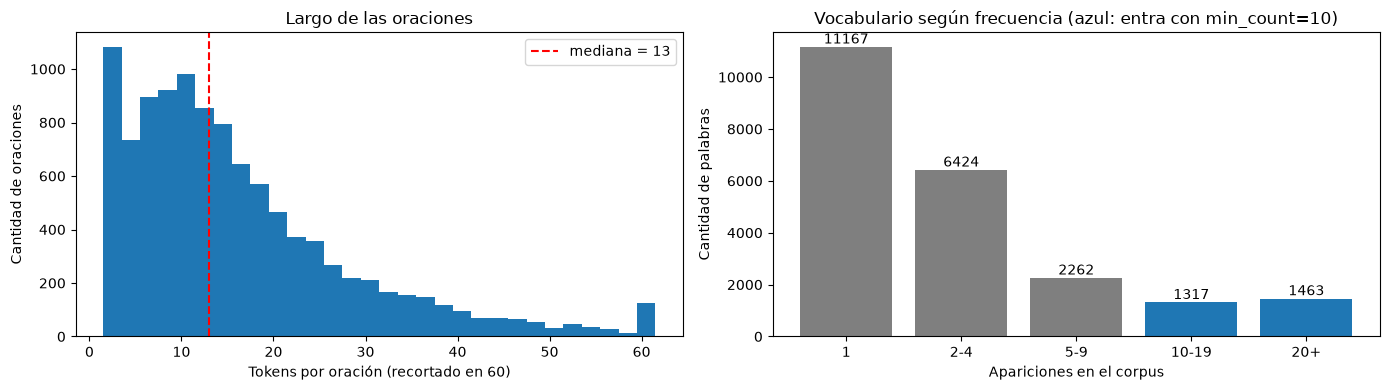

In [28]:
# Los dos histogramas justifican las dos decisiones de la sección siguiente
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Izquierda: largo de las oraciones -> justifica window=5
ax1.hist(largos.clip(upper=60), bins=np.arange(1.5, 62.5, 2))
ax1.axvline(largos.median(), color="red", linestyle="--", label=f"mediana = {int(largos.median())}")
ax1.set_xlabel("Tokens por oración (recortado en 60)")
ax1.set_ylabel("Cantidad de oraciones")
ax1.set_title("Largo de las oraciones")
ax1.legend()

# Derecha: cuántas palabras hay según su frecuencia -> justifica min_count=10
rangos = ["1", "2-4", "5-9", "10-19", "20+"]
cantidades = [(frecuencias == 1).sum(),
              ((frecuencias >= 2) & (frecuencias <= 4)).sum(),
              ((frecuencias >= 5) & (frecuencias <= 9)).sum(),
              ((frecuencias >= 10) & (frecuencias <= 19)).sum(),
              (frecuencias >= 20).sum()]
barras = ax2.bar(rangos, cantidades, color=["tab:gray"] * 3 + ["tab:blue"] * 2)
ax2.bar_label(barras)
ax2.set_xlabel("Apariciones en el corpus")
ax2.set_ylabel("Cantidad de palabras")
ax2.set_title("Vocabulario según frecuencia (azul: entra con min_count=10)")

plt.tight_layout()
plt.show()


**Interpretación del preprocesamiento**

- **Documentos.** 5.192 párrafo, 10.844 oraciones, 10.594 con al menos 2 tokens útiles.
- **Stopwords.** De 381.311 a 173.650 tokens: el 54 % del texto eran palabras funcionales. Se sacan porque, con ventana 5, si están el contexto de cada palabra es "de", "la", "que", que no distinguen significados. La lista de NLTK se amplió a 341 con conectores que omite (`si`, `tan`, `así`, `pues`) y formas del siglo XVII (`desta`, `dél`, `agora`, `ansí`).
- **Vocabulario.** 22.633 palabras distintas, pero 11.167 aparecen una sola vez. Con frecuencia mínima 5 quedan 5.042 y con 10 quedan 2.780. Esto define el `min_count` de la sección siguiente. La mediana de 13 tokens por oración justifica usar `window=5`.
- **Limitaciones.** NLTK corta oraciones en los `!` intermedios, frecuentes en este texto (*"te rogamos, ¡oh discreto Ambrosio!"* queda separado de su continuación). Y sobreviven `ser`, `decir`, `hacer` (infinitivos, que la lista no cubre) y `don`, `señor`, `merced`, que acá son casi muletillas pero son sustantivos.


# 3 - Entrenamiento de los embeddings (Word2Vec)

Los valores se eligen a partir de lo medido en la sección anterior, no por defecto:

| Hiperparámetro | Valor | Por qué |
|---|---|---|
| `sg` | 1 (Skip-gram) | El corpus es chico. |
| `min_count` | 10 | Con 5 entrarían 5.042 palabras, muchas con solo 5 a 9 apariciones en todo el libro: muy pocos contextos para un vector confiable. Con 10 quedan 2.780 palabras, cada una con más información. |
| `window` | 5 | La mediana es de 13 tokens por oración, así que una ventana de 5 entra cómoda y captura relaciones temáticas (de qué se habla) y no solo sintácticas. |
| `vector_size` | 100 | |
| `negative` | 20 | Igual que en clase. |
| `epochs` | 20 | Igual que en clase.|
| `workers`, `seed` | 1, 42 | Con un solo hilo y semilla fija, el entrenamiento da el mismo resultado en cada corrida. |


In [11]:
class callback(CallbackAny2Vec):
    """Callback que imprime y guarda el loss de cada época"""
    def __init__(self):
        self.epoch = 0
        self.loss_previous_step = 0
        self.losses = []

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        loss_epoca = loss if self.epoch == 0 else loss - self.loss_previous_step
        self.losses.append(loss_epoca)
        print("Loss after epoch {}: {}".format(self.epoch, loss_epoca))
        self.epoch += 1
        self.loss_previous_step = loss


In [12]:
# Modelo generador de vectores, con la estructura Skip-gram

w2v_model = Word2Vec(min_count=10,      
                     window=5,          
                     vector_size=100,   
                     negative=20,       
                     workers=1,         
                     seed=42,
                     sg=1)              # modelo 0:CBOW  1:skipgram


In [13]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

print("Cantidad de docs en el corpus:", w2v_model.corpus_count)
print("Cantidad de words distintas en el vocabulario:", len(w2v_model.wv.index_to_key))


Cantidad de docs en el corpus: 10594
Cantidad de words distintas en el vocabulario: 2780


In [14]:
# Entrenamos el modelo generador de vectores
cb = callback()
w2v_model.train(sentence_tokens,
                total_examples=w2v_model.corpus_count,
                epochs=20,
                compute_loss=True,
                callbacks=[cb])


Loss after epoch 0: 2390574.0
Loss after epoch 1: 1788759.75
Loss after epoch 2: 1663635.75
Loss after epoch 3: 1646097.5
Loss after epoch 4: 1610365.0
Loss after epoch 5: 1572906.0
Loss after epoch 6: 1556981.0
Loss after epoch 7: 1546127.0
Loss after epoch 8: 1531046.0
Loss after epoch 9: 1519688.0
Loss after epoch 10: 1474320.0
Loss after epoch 11: 1464772.0
Loss after epoch 12: 1460284.0
Loss after epoch 13: 1447462.0
Loss after epoch 14: 1441468.0
Loss after epoch 15: 1442682.0
Loss after epoch 16: 1437500.0
Loss after epoch 17: 1438426.0
Loss after epoch 18: 1435780.0
Loss after epoch 19: 1436314.0


(2410894, 3473000)

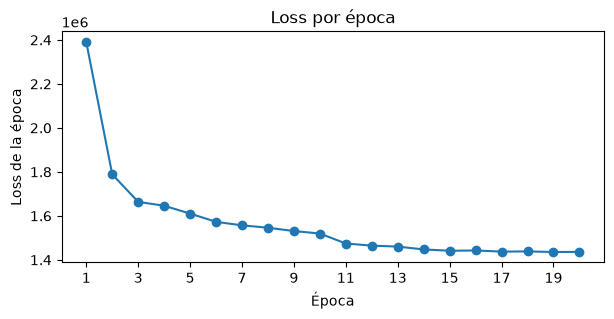

In [15]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, len(cb.losses) + 1), cb.losses, marker="o")
ax.set_xlabel("Época")
ax.set_ylabel("Loss de la época")
ax.set_title("Loss por época")
ax.set_xticks(range(1, len(cb.losses) + 1, 2))
plt.show()


**Interpretación.** El vocabulario quedó en 2.780 palabras sobre 10.594 documentos.

El loss cae fuerte entre la época 1 y la 3 (de 2,39 a 1,66 millones), sigue bajando de forma gradual y desde la época 15 queda plano.

`train()` devuelve `(2410894, 3473000)`: de los 3,47 millones de palabras pasadas al modelo (173.650 tokens × 20 épocas) usó el 69 %. El resto lo descarta el *subsampling* que gensim aplica por defecto (`sample=0.001`) sobre las palabras muy frecuentes, para que `don`, `quijote` y `sancho` no dominen el entrenamiento.

Un loss bajo solo indica que el modelo predice mejor los contextos, no que los vectores sean útiles. Eso se evalúa en las secciones siguientes, mirando vecinos y grupos.


# 4 - Términos de interés

Se eligen términos del vocabulario agrupados en personajes, objetos y lugares, y temas de la novela, incluyendo a propósito un concepto abstracto (`amor`) para ver dónde falla el modelo. Se los compara de a cuatro por tabla.


In [16]:
# Tabla con los términos más similares a cada palabra, para comparar varias a la vez
def tabla_similares(palabras, topn=10):
    return pd.DataFrame({p: [f"{t} ({s:.2f})" for t, s in w2v_model.wv.most_similar(positive=[p], topn=topn)]
                         for p in palabras}, index=range(1, topn + 1))

# Personajes
tabla_similares(["quijote", "sancho", "dulcinea", "cura"])


,quijote,sancho,dulcinea,cura
1,don (0.75),quijote (0.72),toboso (0.75),barbero (0.66)
2,sancho (0.72),calla (0.65),labradora (0.56),nicolás (0.60)
3,álvaro (0.67),don (0.65),encantada (0.54),canónigo (0.54)
4,rióse (0.64),canónigo (0.62),alabanzas (0.54),rebuzno (0.51)
5,despidió (0.62),confieso (0.61),desencanto (0.54),dijeron (0.51)
6,caminantes (0.62),decid (0.61),señora (0.53),camaradas (0.50)
7,volvióse (0.61),place (0.61),fea (0.52),maese (0.50)
8,place (0.61),venid (0.61),prometer (0.51),apostaré (0.49)
9,vivaldo (0.61),deso (0.61),desdeñado (0.50),prosiguiendo (0.49)
10,caminante (0.60),correo (0.60),par (0.50),recibieron (0.49)


In [17]:
# Objetos, animales y lugares
tabla_similares(["rocinante", "yelmo", "ínsula", "venta"])


,rocinante,yelmo,ínsula,venta
1,cabestro (0.65),mambrino (0.91),gobernar (0.66),mesón (0.58)
2,riendas (0.62),bacía (0.78),barataria (0.65),cenar (0.58)
3,subir (0.61),jaez (0.74),gobierno (0.60),caballeriza (0.55)
4,adarga (0.60),saca (0.69),prometida (0.58),posada (0.54)
5,arzón (0.59),albarda (0.64),ínsulas (0.57),lanzas (0.53)
6,rocín (0.59),referido (0.58),mandar (0.56),entraron (0.53)
7,caballeriza (0.58),averiguar (0.58),conde (0.56),procesión (0.52)
8,apeándose (0.58),tocantes (0.58),condado (0.55),patio (0.51)
9,rienda (0.56),rocín (0.58),vasallos (0.54),arriero (0.51)
10,freno (0.56),acomodó (0.57),gobiernos (0.53),cerrada (0.50)


In [18]:
# Temas de la novela y un concepto abstracto
tabla_similares(["libros", "gigantes", "encantadores", "amor"])


,libros,gigantes,encantadores,amor
1,caballerías (0.63),ejércitos (0.72),persiguen (0.78),muestre (0.57)
2,componer (0.60),molinos (0.69),creído (0.60),nace (0.55)
3,mentiras (0.59),malandrines (0.66),quitarme (0.57),alabanza (0.55)
4,autores (0.54),valerosos (0.56),envidia (0.54),alcanza (0.54)
5,papeles (0.54),cuyos (0.56),encantada (0.54),servida (0.52)
6,ingenios (0.54),envidia (0.55),malos (0.53),acompañe (0.52)
7,escritura (0.52),viento (0.55),huye (0.52),fermosura (0.52)
8,dignas (0.52),torres (0.55),encantador (0.52),vencer (0.51)
9,satanás (0.51),quedamos (0.55),acompañe (0.52),desea (0.51)
10,entretenimiento (0.50),encantamentos (0.54),malicia (0.52),naturaleza (0.51)


In [19]:
# ¿Cuántas veces aparece cada término en el corpus?
terminos = ["quijote", "sancho", "dulcinea", "cura", "rocinante", "yelmo",
            "ínsula", "venta", "libros", "gigantes", "encantadores", "amor"]
pd.DataFrame({"apariciones": [w2v_model.wv.get_vecattr(t, "count") for t in terminos]}, index=terminos).T


,quijote,sancho,dulcinea,cura,rocinante,yelmo,ínsula,venta,libros,gigantes,encantadores,amor
apariciones,2174,2148,282,313,207,38,116,139,147,30,63,124


**Interpretación — términos más similares**

- **Personajes:** no traen sinónimos sino escenas. `quijote`↔`sancho` (0,72), y el resto son verbos del diálogo (`calla`, `decid`, `venid`) e interlocutores (`canónigo`, `vivaldo`). El modelo aprende *con quién y dónde* aparece cada uno.
- **Objetos y lugares:** los mejores resultados. `yelmo` → `mambrino` (0,91) y `bacía` (0,78) reconstruye el episodio entero; `dulcinea` → `toboso` (0,75), `labradora`, `encantada`; `ínsula` → `gobernar`, `barataria`. También hay sinonimia real: `venta` → `mesón`, `posada`.
- **Temas:** `gigantes` → `ejércitos` (0,72) y `molinos` (0,69), las dos confusiones famosas. `libros` → `caballerías`, `mentiras`, `autores`.
- **Dónde falla:** `amor` tiene las similitudes más bajas (máximo 0,57) y vecinos dispersos. Un concepto abstracto se usa en contextos variados y su vector queda como un promedio que no está cerca de nada.
- **No manda la frecuencia sino la consistencia del contexto:** `yelmo` (38 apariciones) y `gigantes` (30) dan mejores vecinos que `amor` (124), porque aparecen siempre en el mismo tipo de escena.


In [20]:
# Palabras que MENOS se relacionan con...
for p in ["quijote", "sancho", "dulcinea"]:
    sims = w2v_model.wv.cosine_similarities(w2v_model.wv[p], w2v_model.wv.vectors)
    print(f"{p:<10} similitud contra todo el vocabulario -> mínima: {sims.min():.3f} | mediana: {np.median(sims):.3f}")

pd.DataFrame({p: [f"{t} ({s:.2f})" for t, s in w2v_model.wv.most_similar(negative=[p], topn=8)]
              for p in ["quijote", "sancho", "dulcinea"]}, index=range(1, 9))



quijote    similitud contra todo el vocabulario -> mínima: 0.105 | mediana: 0.332
sancho     similitud contra todo el vocabulario -> mínima: 0.046 | mediana: 0.335
dulcinea   similitud contra todo el vocabulario -> mínima: 0.000 | mediana: 0.226


,quijote,sancho,dulcinea
1,dejé (-0.11),virtud (-0.05),diego (-0.00)
2,carne (-0.11),mostrar (-0.05),cruz (-0.00)
3,dicha (-0.12),belleza (-0.12),presa (-0.01)
4,bienes (-0.12),nobleza (-0.12),fuertemente (-0.02)
5,amor (-0.12),casas (-0.12),fuerza (-0.02)
6,sólo (-0.12),libertad (-0.12),demás (-0.03)
7,mil (-0.13),fuerza (-0.12),capitán (-0.03)
8,nace (-0.13),humana (-0.12),dejasen (-0.03)


**Interpretación — términos menos similares**

- **El signo.** `most_similar(negative=[p])` busca lo más parecido al vector *invertido*, así que muestra la similitud cambiada de signo: `virtud (-0,05)` significa que su similitud real con `sancho` es **+0,05**.
- **No hay opuestos.** La similitud mínima contra todo el vocabulario es 0,105 para `quijote`, 0,046 para `sancho` y 0,000 para `dulcinea`: ningún vector apunta en dirección contraria. Por eso todos los valores de la tabla son negativos.
- **Son palabras sin relación, no antónimos.** Para `sancho` aparecen sustantivos abstractos (`virtud`, `belleza`, `nobleza`, `libertad`). Para `quijote`, `bienes`, `dicha`, `amor`, `nace`.


In [21]:
# Ensayar con palabras que no están en el vocabulario
for palabra in ["computadora", "astillero", "aldonza"]:
    try:
        print(palabra, "->", w2v_model.wv.most_similar(positive=[palabra], topn=3))
    except KeyError:
        print(f"{palabra:<13} -> KeyError: no está en el vocabulario."
              f" Apariciones en el corpus: {frecuencias.get(palabra, 0)}")


computadora   -> KeyError: no está en el vocabulario. Apariciones en el corpus: 0
astillero     -> KeyError: no está en el vocabulario. Apariciones en el corpus: 2
aldonza       -> KeyError: no está en el vocabulario. Apariciones en el corpus: 7


**Interpretación.** El modelo solo conoce su vocabulario y para cualquier otra palabra da `KeyError`, pero por dos motivos distintos: `computadora` no existe en el libro, mientras que `astillero` y `aldonza` (nombre real de Dulcinea) sí están en el texto y quedaron afuera por `min_count=10`. Ese es el costo de esa decisión: vectores más confiables a cambio de perder palabras poco frecuentes. Es una limitación propia de Word2Vec.



# 5 - Reducción de dimensionalidad y visualización en 2D con t-SNE

In [22]:
def reduce_dimensions(model, num_dimensions=2):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

vecs, labels = reduce_dimensions(w2v_model)
print("Embeddings originales:", w2v_model.wv.vectors.shape, "-> proyectados:", vecs.shape)


Embeddings originales: (2780, 100) -> proyectados: (2780, 2)


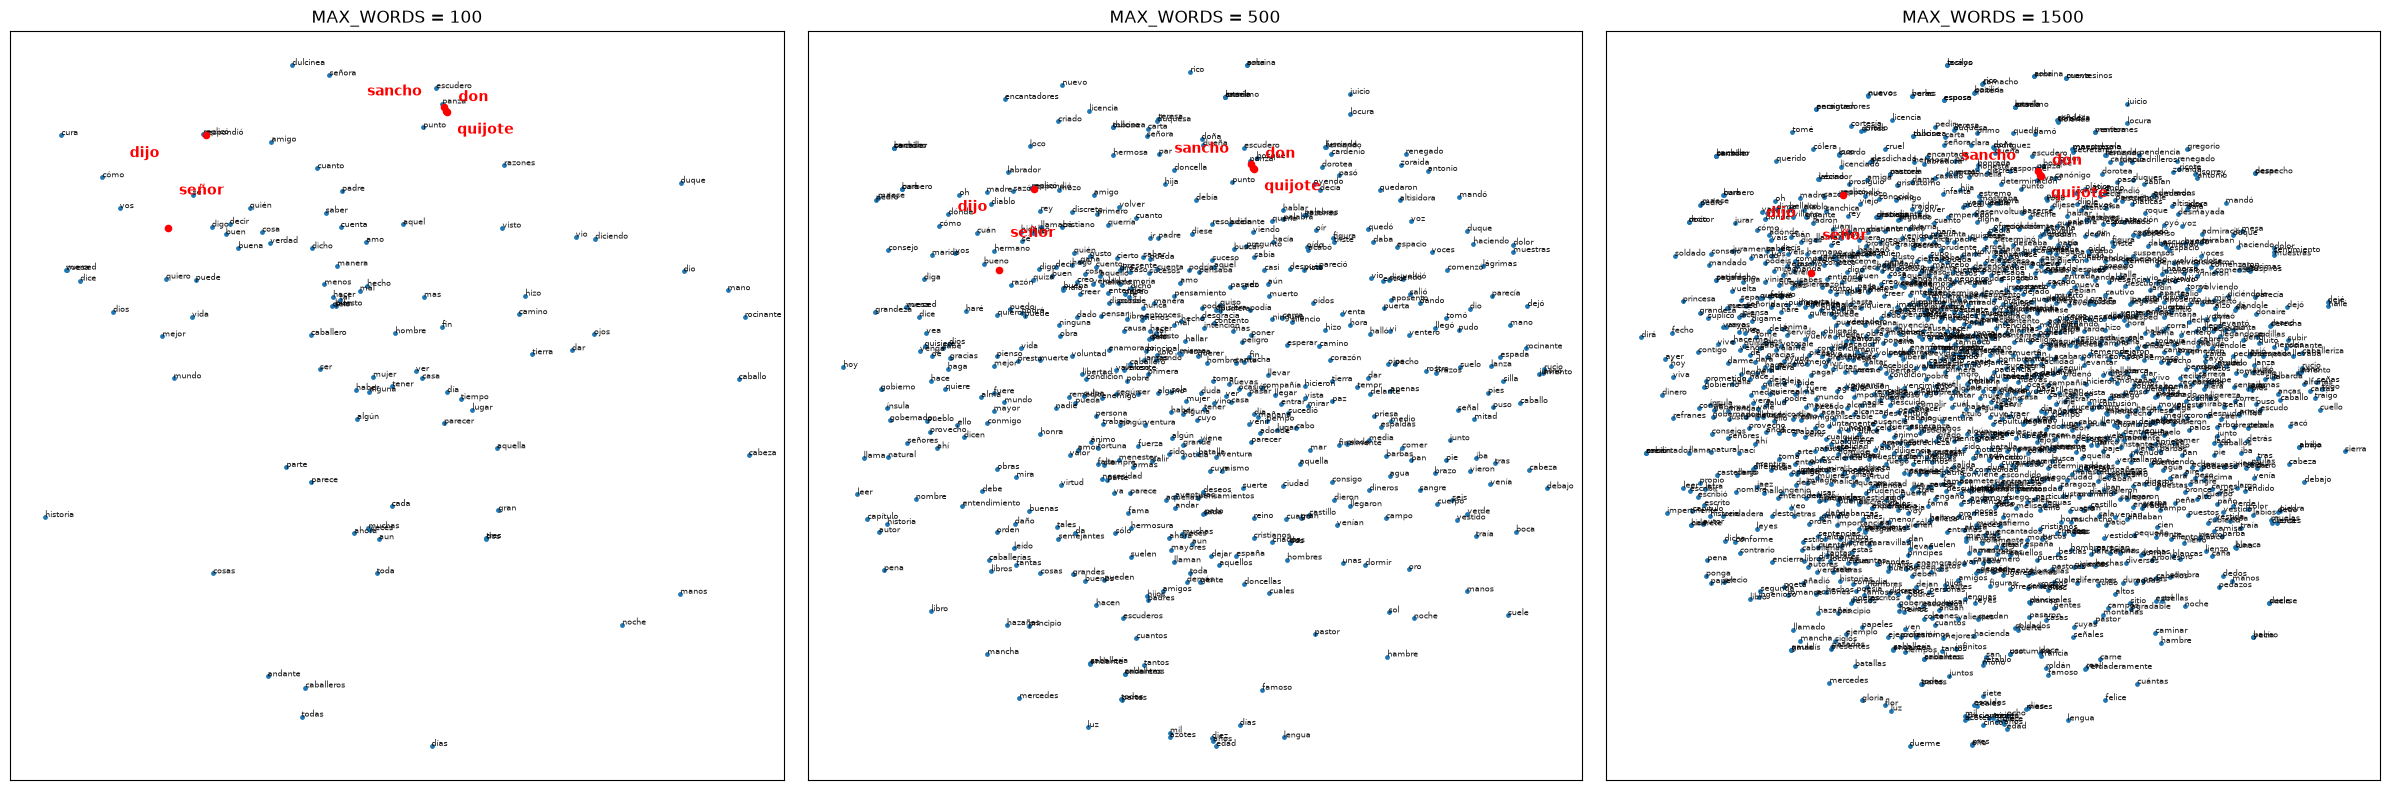

In [23]:
# Comparar tres valores de MAX_WORDS para elegir uno.
# Las 5 palabras más frecuentes se marcan en rojo.
DESTACADAS = list(labels[:5])
indice = {p: i for i, p in enumerate(labels)}
OFFSETS = [(8, 8), (8, -16), (-55, 8), (-55, -16), (8, 24)] 
def mapa(n, ax):
    ax.scatter(vecs[:n, 0], vecs[:n, 1], s=6)
    for i in range(n):
        if labels[i] not in DESTACADAS:
            ax.annotate(labels[i], (vecs[i, 0], vecs[i, 1]), fontsize=6, alpha=0.9)
    for k, p in enumerate(DESTACADAS):
        i = indice[p]
        ax.scatter(vecs[i, 0], vecs[i, 1], s=20, color="red", zorder=3)
        ax.annotate(p, (vecs[i, 0], vecs[i, 1]), xytext=OFFSETS[k % len(OFFSETS)],
                    textcoords="offset points", fontsize=10, color="red", weight="bold", zorder=4)

    ax.set_title(f"MAX_WORDS = {n}")
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for ax, n in zip(axes, [100, 500, 1500]):
    mapa(n, ax)
plt.tight_layout()
plt.show()



In [24]:
# Graficar los embeddings en 2D 
MAX_WORDS = 500

fig = px.scatter(x=vecs[:MAX_WORDS, 0], y=vecs[:MAX_WORDS, 1], text=labels[:MAX_WORDS],
                 title=f"t-SNE en 2D de las {MAX_WORDS} palabras más frecuentes")
fig.update_traces(marker_size=4, textposition="top center", textfont_size=9)
fig.update_layout(height=800)
fig.show()


In [25]:
# Las 10 palabras más cercanas en el gráfico a cada una de las destacadas.
# Se mide la distancia sobre el plano 2D, entre las MAX_WORDS que se grafican.
def vecinos_en_el_grafico(palabra, topn=10, max_words=MAX_WORDS):
    i = indice[palabra]
    puntos = vecs[:max_words]
    distancias = np.linalg.norm(puntos - vecs[i], axis=1)
    return [f"{labels[j]} ({distancias[j]:.1f})" for j in np.argsort(distancias)[1:topn + 1]]

# ¿Cuántas de esas vecinas coinciden con las que da most_similar en las 100 dimensiones?
for p in DESTACADAS:
    en_grafico = {v.split(" ")[0] for v in vecinos_en_el_grafico(p)}
    originales = {t for t, _ in w2v_model.wv.most_similar(p, topn=10)}
    print(f"{p:<10} vecinas que coinciden con las de most_similar: {len(en_grafico & originales)} de 10")

pd.DataFrame({p: vecinos_en_el_grafico(p) for p in DESTACADAS}, index=range(1, 11))


don        vecinas que coinciden con las de most_similar: 2 de 10
quijote    vecinas que coinciden con las de most_similar: 2 de 10
sancho     vecinas que coinciden con las de most_similar: 2 de 10
dijo       vecinas que coinciden con las de most_similar: 2 de 10
señor      vecinas que coinciden con las de most_similar: 0 de 10


,don,quijote,sancho,dijo,señor
1,quijote (0.1),don (0.1),panza (0.3),respondió (0.1),bueno (1.6)
2,sancho (0.6),sancho (0.5),quijote (0.5),replicó (0.3),razón (1.9)
3,panza (0.9),panza (0.8),don (0.6),sazón (2.0),hermano (2.0)
4,bosque (1.1),bosque (1.0),bosque (0.8),rey (2.3),quizá (3.4)
5,escudero (2.3),escudero (2.2),escudero (1.7),mozo (2.4),sé (3.6)
6,punto (2.5),punto (2.5),punto (2.6),labrador (3.0),digo (3.9)
7,hablar (5.0),hablar (5.1),dueña (5.0),llamaba (3.9),puedo (4.0)
8,dueña (5.5),dueña (5.3),doña (5.3),loco (4.3),cuán (4.3)
9,quería (5.5),quería (5.6),hablar (5.6),discreto (4.3),hidalgo (4.4)
10,palabra (5.8),doña (5.8),quería (6.1),diablo (4.4),quiero (4.5)


**Elección de `MAX_WORDS`.** Con **100** se lee perfecto pero casi todo son palabras genéricas (`cosa`, `bien`, `mundo`) y no hay grupos que interpretar. Con **1.500** las etiquetas se superponen hasta formar una mancha ilegible. Con **500** se leen salvo en las zonas densas y ya aparecen grupos con sentido.



# 6 - Grupos de palabras

Para inspeccionar el gráfico se define una función que genera la **captura** de una zona: hace zoom alrededor de una palabra y muestra sus vecinas más cercanas en el plano. Las capturas se generan por código, en lugar de pegar imágenes a mano, para que correspondan siempre al gráfico de esta misma corrida.

El zoom muestra unas 20 etiquetas, así que no hay problema de legibilidad y se usa todo el vocabulario en vez de las 500 palabras del gráfico general. Eso permite que entren palabras poco frecuentes pero centrales en la novela, como `molinos`, que está en el puesto 2.328.


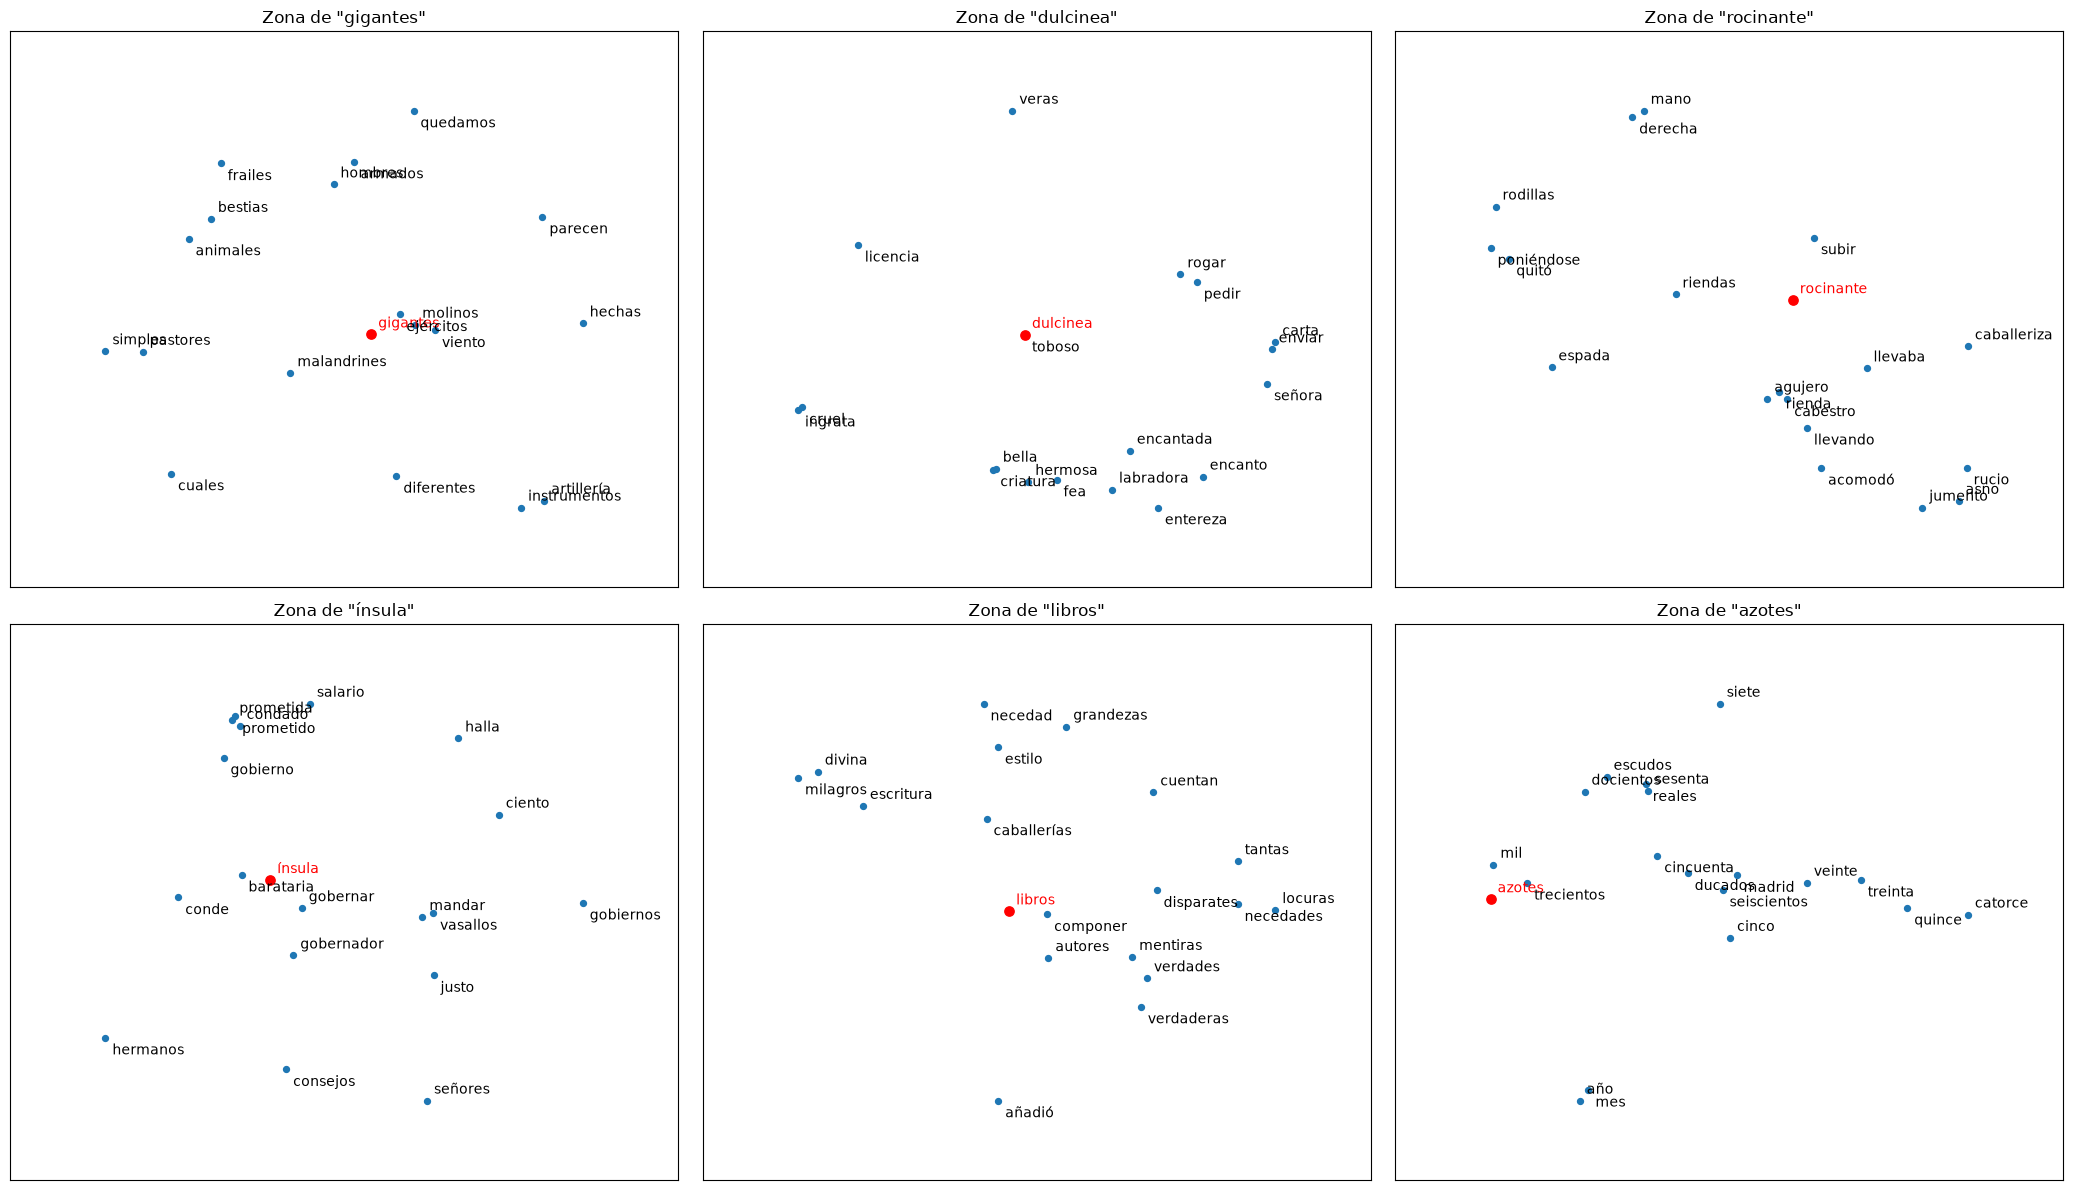

In [26]:
# Captura de una zona del mapa: zoom alrededor de una palabra, con sus k vecinas más cercanas.
# Se usa todo el vocabulario y no solo las MAX_WORDS del gráfico general: como el zoom muestra
# unas 20 etiquetas, no hay problema de legibilidad, y así entran palabras poco frecuentes pero
# centrales en la novela (por ejemplo "molinos", que está en el puesto 2.328).
def captura(palabra, k=18, ax=None):
    i = indice[palabra]
    distancias = np.linalg.norm(vecs - vecs[i], axis=1)
    cerca = np.argsort(distancias)[:k + 1]

    ax.scatter(vecs[cerca, 0], vecs[cerca, 1], s=18)
    ax.scatter(vecs[i, 0], vecs[i, 1], s=45, color="red", zorder=3)
    # las etiquetas se alternan arriba y abajo del punto para que no se superpongan
    for n, j in enumerate(cerca):
        ax.annotate(labels[j], vecs[j], xytext=(5, 5) if n % 2 == 0 else (5, -12),
                    textcoords="offset points", fontsize=10, color="red" if j == i else "black")
    ax.margins(0.2)
    ax.set_title(f'Zona de "{palabra}"')
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
for ax, zona in zip(axes.ravel(), ["gigantes", "dulcinea", "rocinante", "ínsula", "libros", "azotes"]):
    captura(zona, ax=ax)
plt.tight_layout()
plt.show()




**Grupo 1 — Lo que don Quijote confunde (`gigantes`).** `molinos`, `viento`, `ejércitos`, `malandrines`, `frailes`, `pastores`, `bestias`, `armados`. No son cosas parecidas entre sí: son todo lo que el protagonista toma por enemigos. El modelo reconstruyó el mecanismo central del libro.

**Grupo 2 — La dama (`dulcinea`).** Sus dos caras: la idealizada (`hermosa`, `bella`, `señora`) y la real o encantada (`labradora`, `fea`, `encantada`, `encanto`), más `toboso`, `carta` y `enviar`.

**Grupo 3 — Montar y pelear (`rocinante`).** Animales (`rucio`, `jumento`), arreos (`riendas`, `silla`, `albarda`, `alforjas`) y verbos de acción (`arremetió`, `asió`, `subió`). No agrupó "cosas de caballo" sino **la escena**.

**Grupo 4 — El gobierno de la ínsula (`ínsula`).** `gobierno`, `gobernar`, `gobernador`, `mandar`, `consejos`, más `refranes` y `médico`. Un episodio de pocos capítulos condensado en una zona.

**Grupo 5 — El mundo de los libros (`libros`).** `caballerías`, `autores`, `poeta`, `estilo`, `historias`. Lo más interesante es que `disparates` y `locuras` caen pegadas: no es solo el tema, es el **juicio** que la novela hace sobre los libros de caballerías.

**Grupo 6 — Números, dinero y tiempo (`azotes`).** `mil`, `trecientos`, `escudos`, `reales`, `años`, `mes`. Nadie le indicó al modelo qué es un número: los agrupa porque comparten contexto, delante de algo que se cuenta. `azotes` cae acá por los tres mil trescientos que Sancho debe darse.



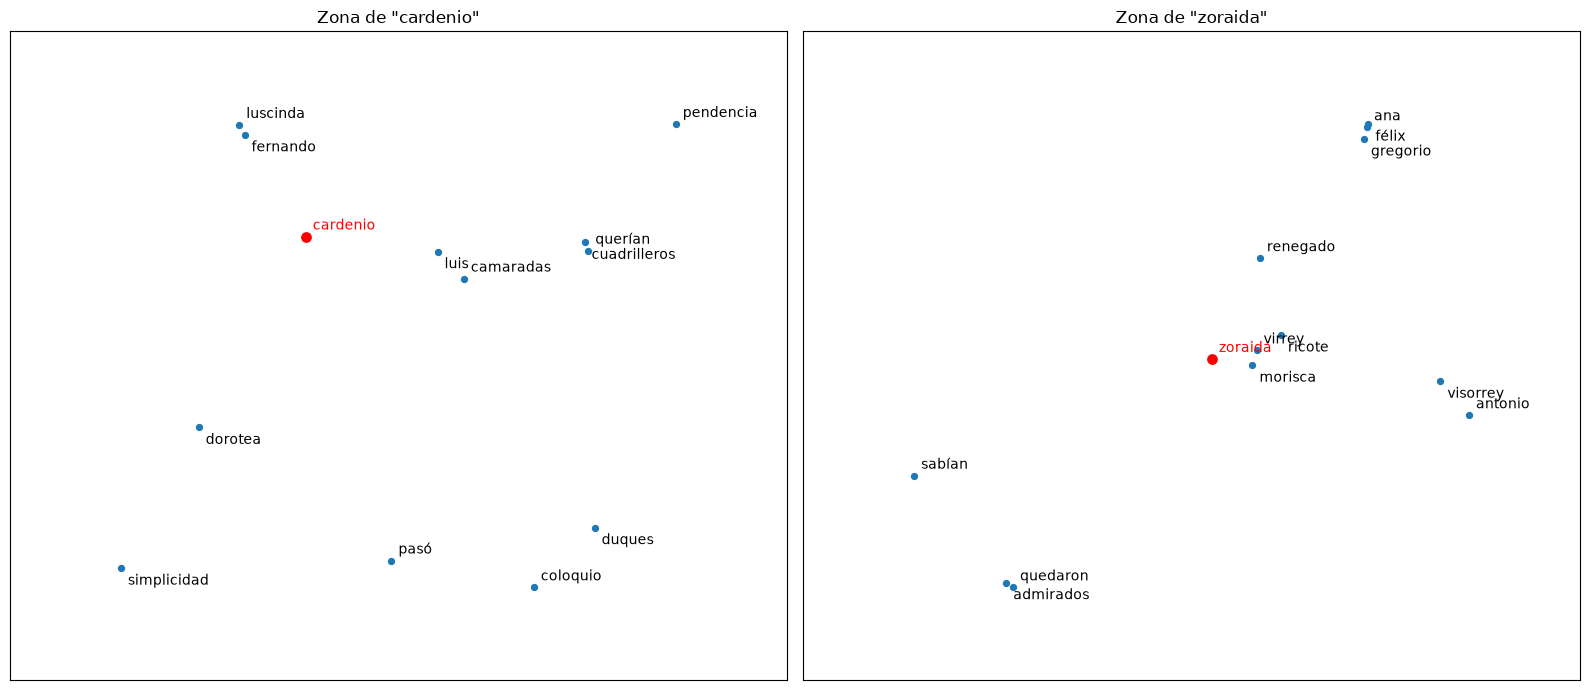

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, zona in zip(axes, ["cardenio", "zoraida"]):
    captura(zona, k=12, ax=ax)
plt.tight_layout()
plt.show()



**Grupos 7 y 8 — Las historias intercaladas.** Alrededor de `cardenio` están `luscinda`, `fernando`, `dorotea` y `luis`: los protagonistas de la historia de amores cruzados de la primera parte. Alrededor de `zoraida` están `renegado`, `ricote`, `morisca`, `ana`, `félix` y `gregorio`, el vocabulario del cautivo de Argel y de Ana Félix.

**Conclusión.** Las historias intercaladas forman **islas**, tienen personajes propios que casi no comparten escenas con el resto del libro, así que sus vectores quedan lejos del núcleo `quijote` y `sancho`. El modelo reconstruyó la estructura narrativa de la novela sin que nadie se la indicara.


# 7 - Conclusiones

**1. Qué aprendió.** Con un solo libro (173.650 tokens, 2.780 palabras) Word2Vec recuperó relaciones reales de la novela sin información externa: los gigantes con los molinos, Dulcinea con el Toboso y el encantamiento, la ínsula con Barataria.

**2. Qué tipo de similitud captura.** Con Skip-gram y ventana 5, "similar" significa **"aparece en las mismas escenas"**, no "significa lo mismo": los vecinos de un personaje son sus interlocutores, y los de un objeto son el episodio donde aparece.

**3. Los grupos son de tres tipos.** Temáticos (libros, gobierno), abstractos (números, dinero y tiempo, agrupados sin que nadie le dijera al modelo qué es un número) y narrativos (cada historia intercalada forma una isla).

**4. Limitaciones.** Los conceptos abstractos fallan, como `amor` que da peores vecinos que `yelmo`, que aparece un tercio de las veces, por lo que importa la consistencia del contexto, no la frecuencia. Las formas de una misma palabra quedan lejos. Las "menos similares" no son antónimos sino palabras sin relación. Y al proyectar a 2D solo 2 de cada 10 vecinas se conservan.

**5. Qué haría distinto.** Sumar más texto del mismo autor y época, para que los vectores no dependan de episodios puntuales y lematizar o usar fastText para las formas de una misma palabra.

